<p align="center" style="background-color:#f2f2f2; padding:15px; border-radius:10px;">

<span style="color:Blue; font-size:36px; font-family:Arial; font-weight:bold;">
Customer Service Requests Analysis
</span>

</p>



# Create Sections
## 1. Import Libraries
## 2. Load Dataset
## 3. Understand Dataset
## 4. Data Cleaning
## 5. Exploratory Data Analysis
## 6. Complaint Analysis
## 7. Statistical Testing
## 8. Observations

In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns 
from scipy import stats 

%matplotlib inline 

In [2]:
df = pd.read_csv("311_Service_Requests_from_2010_to_Present.csv")
df.head()

C:\Users\HP\AppData\Local\Temp\ipykernel_9444\1741486433.py:1: DtypeWarning: Columns (0: Ferry Direction, 1: Ferry Terminal Name) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("311_Service_Requests_from_2010_to_Present.csv")


,Unique Key,Created Date,Closed Date,Agency,Agency Name,Complaint Type,Descriptor,Location Type,Incident Zip,Incident Address,...,Bridge Highway Name,Bridge Highway Direction,Road Ramp,Bridge Highway Segment,Garage Lot Name,Ferry Direction,Ferry Terminal Name,Latitude,Longitude,Location
0,32310363,12/31/2015 11:59:45 PM,01/01/2016 12:55:15 AM,NYPD,New York City Police Department,Noise - Street/Sidewalk,Loud Music/Party,Street/Sidewalk,10034.0,71 VERMILYEA AVENUE,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.865682,-73.923501,"(40.86568153633767, -73.92350095571744)"
1,32309934,12/31/2015 11:59:44 PM,01/01/2016 01:26:57 AM,NYPD,New York City Police Department,Blocked Driveway,No Access,Street/Sidewalk,11105.0,27-07 23 AVENUE,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.775945,-73.915094,"(40.775945312321085, -73.91509393898605)"
2,32309159,12/31/2015 11:59:29 PM,01/01/2016 04:51:03 AM,NYPD,New York City Police Department,Blocked Driveway,No Access,Street/Sidewalk,10458.0,2897 VALENTINE AVENUE,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.870325,-73.888525,"(40.870324522111424, -73.88852464418646)"
3,32305098,12/31/2015 11:57:46 PM,01/01/2016 07:43:13 AM,NYPD,New York City Police Department,Illegal Parking,Commercial Overnight Parking,Street/Sidewalk,10461.0,2940 BAISLEY AVENUE,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.835994,-73.828379,"(40.83599404683083, -73.82837939584206)"
4,32306529,12/31/2015 11:56:58 PM,01/01/2016 03:24:42 AM,NYPD,New York City Police Department,Illegal Parking,Blocked Sidewalk,Street/Sidewalk,11373.0,87-14 57 ROAD,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.733060,-73.874170,"(40.733059618956815, -73.87416975810375)"


In [3]:
df.columns

Index(['Unique Key', 'Created Date', 'Closed Date', 'Agency', 'Agency Name',
       'Complaint Type', 'Descriptor', 'Location Type', 'Incident Zip',
       'Incident Address', 'Street Name', 'Cross Street 1', 'Cross Street 2',
       'Intersection Street 1', 'Intersection Street 2', 'Address Type',
       'City', 'Landmark', 'Facility Type', 'Status', 'Due Date',
       'Resolution Description', 'Resolution Action Updated Date',
       'Community Board', 'Borough', 'X Coordinate (State Plane)',
       'Y Coordinate (State Plane)', 'Park Facility Name', 'Park Borough',
       'School Name', 'School Number', 'School Region', 'School Code',
       'School Phone Number', 'School Address', 'School City', 'School State',
       'School Zip', 'School Not Found', 'School or Citywide Complaint',
       'Vehicle Type', 'Taxi Company Borough', 'Taxi Pick Up Location',
       'Bridge Highway Name', 'Bridge Highway Direction', 'Road Ramp',
       'Bridge Highway Segment', 'Garage Lot Name', 'Ferry 

In [4]:
df.shape

(364558, 53)

In [5]:
df.isnull().sum()

Unique Key                             0
Created Date                           0
Closed Date                         2381
Agency                                 0
Agency Name                            0
Complaint Type                         0
Descriptor                          6501
Location Type                        133
Incident Zip                        2998
Incident Address                   51699
Street Name                        51699
Cross Street 1                     57188
Cross Street 2                     57805
Intersection Street 1             313438
Intersection Street 2             314046
Address Type                        3252
City                                2997
Landmark                          364183
Facility Type                       2389
Status                                 0
Due Date                               3
Resolution Description                 0
Resolution Action Updated Date      2402
Community Board                        0
Borough         

In [6]:
df.columns = df.columns.str.strip()
df.columns

Index(['Unique Key', 'Created Date', 'Closed Date', 'Agency', 'Agency Name',
       'Complaint Type', 'Descriptor', 'Location Type', 'Incident Zip',
       'Incident Address', 'Street Name', 'Cross Street 1', 'Cross Street 2',
       'Intersection Street 1', 'Intersection Street 2', 'Address Type',
       'City', 'Landmark', 'Facility Type', 'Status', 'Due Date',
       'Resolution Description', 'Resolution Action Updated Date',
       'Community Board', 'Borough', 'X Coordinate (State Plane)',
       'Y Coordinate (State Plane)', 'Park Facility Name', 'Park Borough',
       'School Name', 'School Number', 'School Region', 'School Code',
       'School Phone Number', 'School Address', 'School City', 'School State',
       'School Zip', 'School Not Found', 'School or Citywide Complaint',
       'Vehicle Type', 'Taxi Company Borough', 'Taxi Pick Up Location',
       'Bridge Highway Name', 'Bridge Highway Direction', 'Road Ramp',
       'Bridge Highway Segment', 'Garage Lot Name', 'Ferry 

In [7]:
df = df[df['Closed Date'].notnull()]
df.shape

(362177, 53)

In [8]:
df['Created Date'] = pd.to_datetime(df['Created Date'], errors='coerce')
df['Closed Date'] = pd.to_datetime(df['Closed Date'], errors='coerce')

C:\Users\HP\AppData\Local\Temp\ipykernel_9444\12745884.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Created Date'] = pd.to_datetime(df['Created Date'], errors='coerce')
C:\Users\HP\AppData\Local\Temp\ipykernel_9444\12745884.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Closed Date'] = pd.to_datetime(df['Closed Date'], errors='coerce')


In [9]:
df[['Created Date','Closed Date']].isnull().sum()

Created Date    0
Closed Date     0
dtype: int64

In [10]:
df = df[df['Closed Date'] >= df['Created Date']]
df.shape

(362177, 53)

In [11]:
df['Request_Closing_Time'] = (
    df['Closed Date'] - df['Created Date']
).dt.total_seconds()

In [12]:
df['Request_Closing_Time'].describe()

count    3.621770e+05
mean     1.511330e+04
std      2.110255e+04
min      6.100000e+01
25%      4.533000e+03
50%      9.616000e+03
75%      1.887800e+04
max      2.134342e+06
Name: Request_Closing_Time, dtype: float64

In [13]:
df['City'] = df['City'].fillna("Unknown City")

In [14]:
df['City'].isnull().sum()

np.int64(0)

In [15]:
df = df.drop(columns=[
    'School Name','School Number','School Region',
    'School Code','School Phone Number',
    'School Address','School City','School State',
    'School Zip','School Not Found'
], errors='ignore')

# NULL values graph

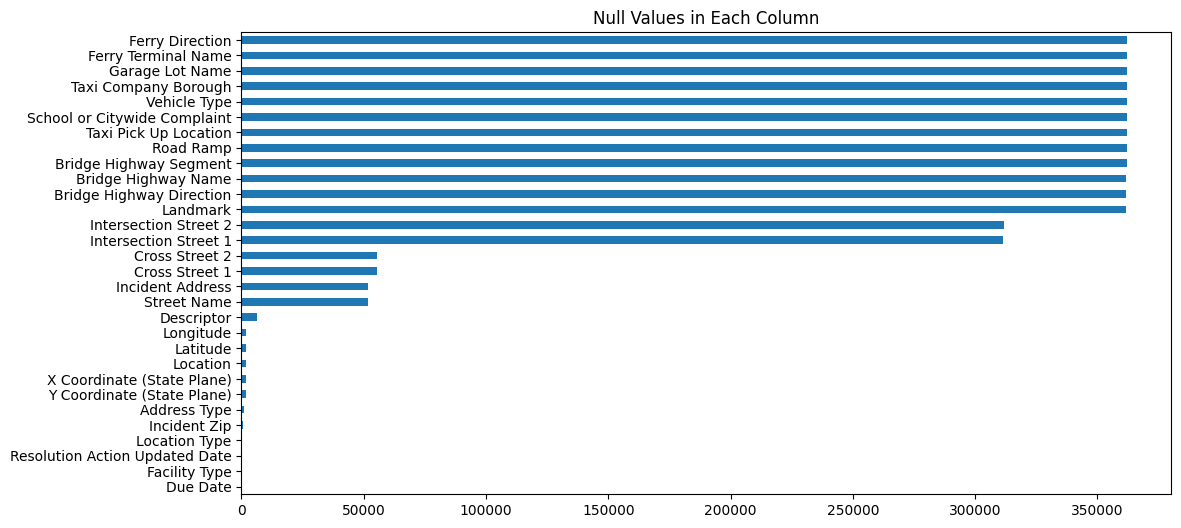

In [16]:
null_values = df.isnull().sum()
null_values = null_values[null_values > 0]

plt.figure(figsize=(12,6))
null_values.sort_values().plot(kind='barh')
plt.title("Null Values in Each Column")
plt.show()

# Complaints in Each City

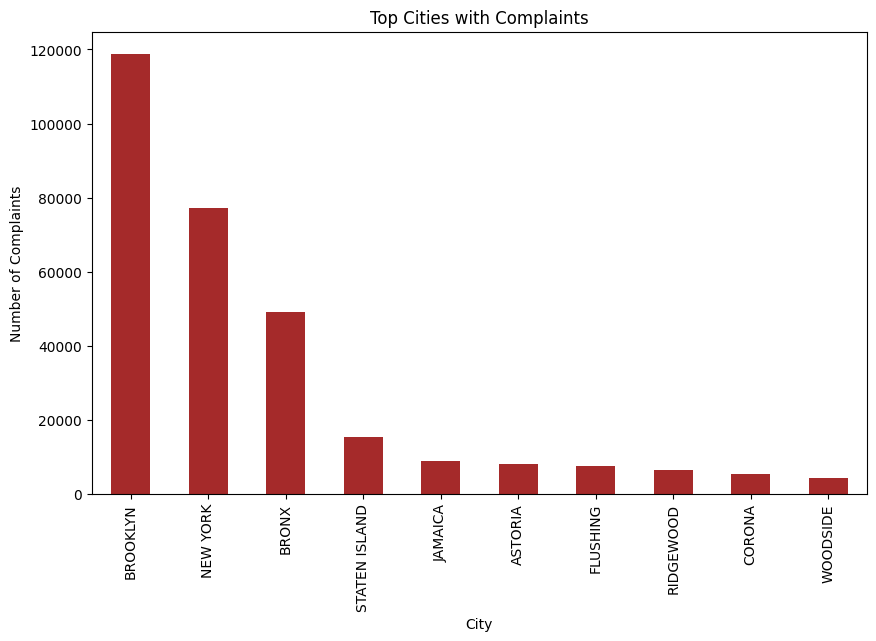

In [17]:
plt.figure(figsize=(10,6))
df['City'].value_counts().head(10).plot(kind='bar', color = 'brown')
plt.title("Top Cities with Complaints")
plt.xlabel("City")
plt.ylabel("Number of Complaints")
plt.show()

# Scatter Plot (Brooklyn)

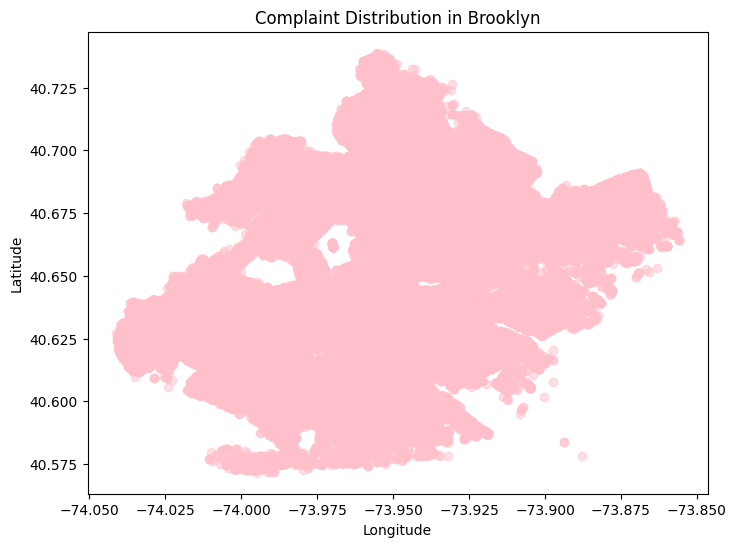

In [18]:
brooklyn = df[df['Borough'] == 'BROOKLYN']

plt.figure(figsize=(8,6))
plt.scatter(brooklyn['Longitude'], brooklyn['Latitude'], alpha=0.5, color = 'pink')
plt.title("Complaint Distribution in Brooklyn")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

# COMPLAINT ANALYSIS

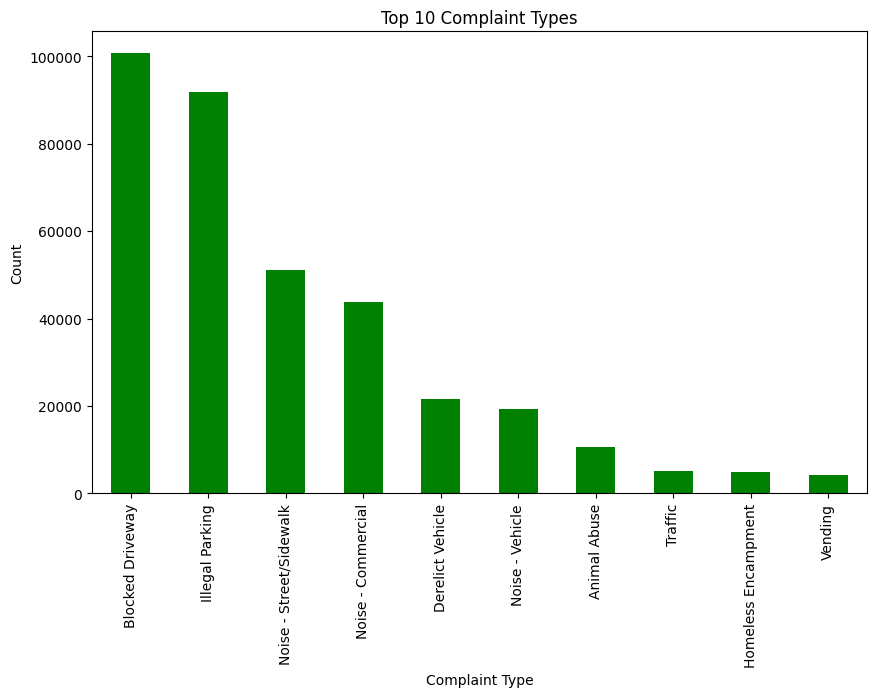

In [19]:
plt.figure(figsize=(10,6))
df['Complaint Type'].value_counts().head(10).plot(kind='bar', color = 'green')
plt.title("Top 10 Complaint Types")
plt.xlabel("Complaint Type")
plt.ylabel("Count")
plt.show()

In [20]:
nyc = df[df['City'] == 'NEW YORK']

nyc['Complaint Type'].value_counts().head(10)

Complaint Type
Noise - Street/Sidewalk    22245
Noise - Commercial         18686
Illegal Parking            14549
Noise - Vehicle             6294
Homeless Encampment         3060
Blocked Driveway            2705
Vending                     2638
Animal Abuse                1941
Traffic                     1769
Noise - Park                1243
Name: count, dtype: int64

In [21]:
top10 = df['Complaint Type'].value_counts().head(10)
top10

Complaint Type
Blocked Driveway           100624
Illegal Parking             91716
Noise - Street/Sidewalk     51139
Noise - Commercial          43751
Derelict Vehicle            21518
Noise - Vehicle             19301
Animal Abuse                10530
Traffic                      5196
Homeless Encampment          4879
Vending                      4185
Name: count, dtype: int64

In [22]:
city_complaints = df.groupby(['City','Complaint Type']).size()
city_complaints

City      Complaint Type         
ARVERNE   Animal Abuse                46
          Blocked Driveway            50
          Derelict Vehicle            32
          Disorderly Youth             2
          Drinking                     1
                                    ... 
Woodside  Blocked Driveway            27
          Derelict Vehicle             8
          Illegal Parking            124
          Noise - Commercial           2
          Noise - Street/Sidewalk      5
Length: 792, dtype: int64

# Pivot Table

In [23]:
df_new = df.pivot_table(index='Complaint Type', columns='City', aggfunc='size', fill_value=0)
df_new

City,ARVERNE,ASTORIA,Astoria,BAYSIDE,BELLEROSE,BREEZY POINT,BRONX,BROOKLYN,CAMBRIA HEIGHTS,CENTRAL PARK,...,SOUTH OZONE PARK,SOUTH RICHMOND HILL,SPRINGFIELD GARDENS,STATEN ISLAND,SUNNYSIDE,Unknown City,WHITESTONE,WOODHAVEN,WOODSIDE,Woodside
Complaint Type,,,,,,,,,,,,,,,,,,,,,
Agency Issues,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,8,0,0,0,0
Animal Abuse,46,170,0,53,15,2,1971,3191,15,0,...,74,40,42,786,40,1,43,57,111,0
Animal in a Park,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Bike/Roller/Skate Chronic,0,16,0,0,1,0,22,124,0,0,...,1,1,0,10,2,2,4,2,5,0
Blocked Driveway,50,3436,159,514,138,3,17062,36445,177,0,...,1202,1946,330,2845,278,86,279,1363,2038,27
Derelict Vehicle,32,426,14,231,120,3,2402,6257,148,0,...,425,356,267,2184,17,63,279,369,298,8
Disorderly Youth,2,5,0,2,2,0,66,79,0,0,...,2,2,0,25,2,0,1,0,1,0
Drinking,1,43,0,1,1,1,206,291,0,0,...,14,25,6,188,12,3,3,4,15,0
Graffiti,1,4,0,3,0,0,15,60,0,0,...,2,0,0,6,1,0,1,0,4,0


# VISUALIZATION

# Complaint Types per City

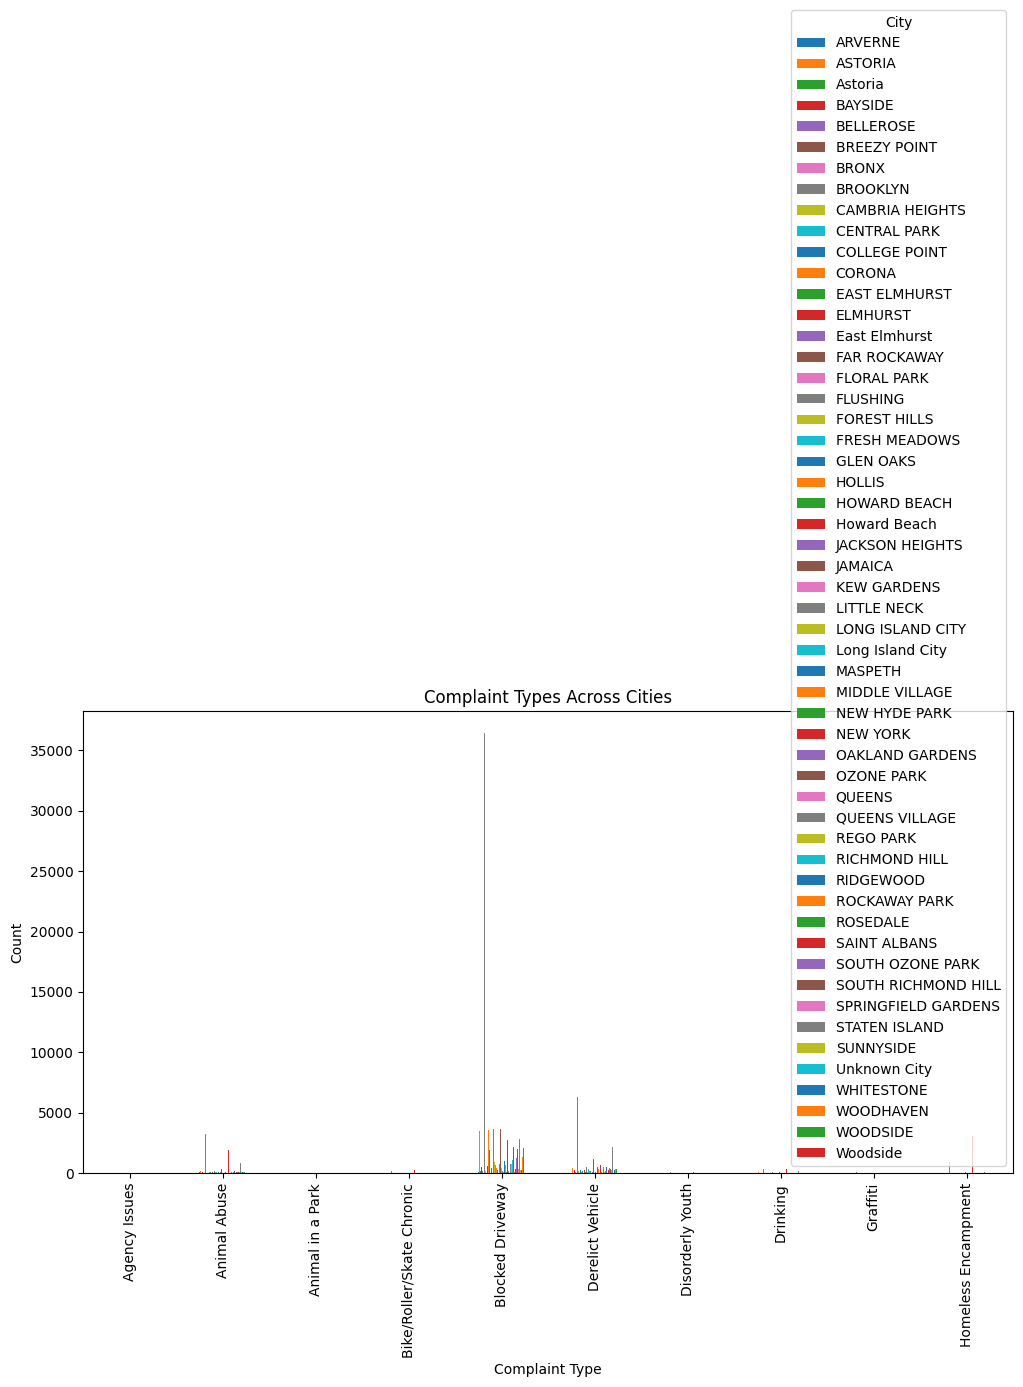

In [24]:
df_new.head(10).plot(kind='bar', figsize=(12,6))
plt.title("Complaint Types Across Cities")
plt.ylabel("Count")
plt.show()

In [25]:
avg_time = df.groupby('Complaint Type')['Request_Closing_Time'].mean().sort_values()
avg_time.head(10)

Complaint Type
Posting Advertisement        7286.256259
Illegal Fireworks           10113.482558
Noise - Commercial          11085.760531
Noise - House of Worship    11391.087079
Noise - Park                12226.055515
Noise - Street/Sidewalk     12231.295411
Traffic                     12309.120092
Disorderly Youth            12363.749206
Noise - Vehicle             12561.800010
Urinating in Public         12959.293292
Name: Request_Closing_Time, dtype: float64

# Visualize Average Closing Time

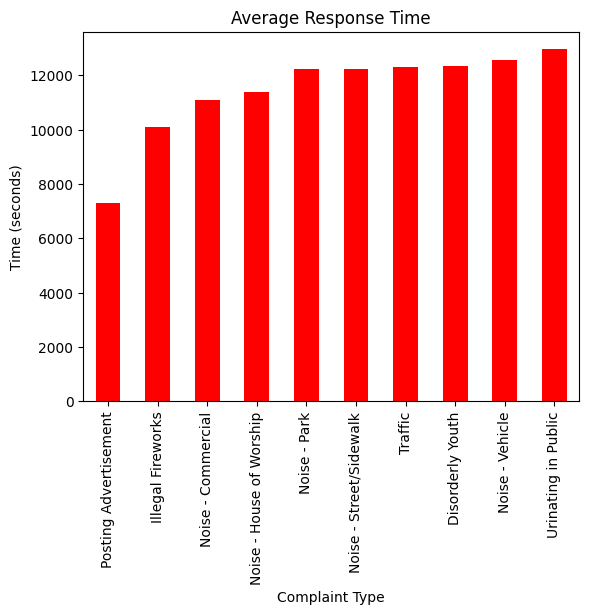

In [26]:
avg_time.head(10).plot(kind='bar', color = 'red')
plt.title("Average Response Time")
plt.ylabel("Time (seconds)")
plt.show()

# STATISTICAL TEST (Kruskal-Wallis)

In [27]:
groups = df.groupby('Complaint Type')['Request_Closing_Time'].apply(list)

# Kruskal Test

In [28]:
from scipy.stats import kruskal

kruskal(*groups[:5])

KruskalResult(statistic=np.float64(65.47298435906306), pvalue=np.float64(2.0456061161139882e-13))

# Interpretation 
Based on the Kruskal-Wallis test, the p-value is less than 0.05. Therefore, we reject the null hypothesis (H0). This indicates that there is a significant difference in response times across different complaint types.

# OBSERVATIONS

1. The dataset contains multiple types of complaints across different cities.

2. The most frequent complaints are related to noise, illegal parking, and blocked driveways.

3. New York City has the highest number of complaints compared to other cities.

4. The average response time varies depending on the type of complaint.

5. Some complaints are resolved quickly, while others take longer time.

6. Based on the Kruskal-Wallis test, there is a significant difference in response times across complaint types (if p-value < 0.05).